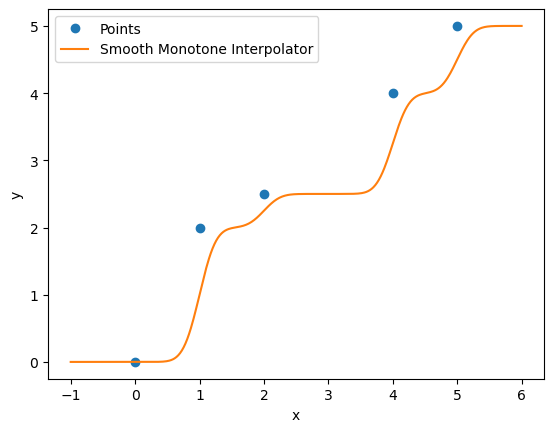

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

def smooth_step(x, k, center):
    """Sigmoidal smooth step centered at `center` with steepness k."""
    return 0.5 * (1 + erf(k * (x - center) / sqrt(2)))

def smooth_monotone_interpolator(x_vals, y_vals, k = 5):
    """Construct a smooth, monotone interpolator from points."""
    assert all(x_vals[i] < x_vals[i+1] for i in range(len(x_vals)-1))
    assert all(y_vals[i] <= y_vals[i+1] for i in range(len(y_vals)-1))
  
    def interpolator(x):
        result = y_vals[0]
        for i in range(1, len(x_vals)):
            result += (y_vals[i] - y_vals[i-1]) * smooth_step(x, k, x_vals[i])
        return result
    
    return interpolator

# Sample points
x_vals = [0, 1, 2, 4, 5]
y_vals = [0, 2, 2.5, 4, 5]

# Build interpolator
f = smooth_monotone_interpolator(x_vals, y_vals, k = 5)

# Plot result
xs = np.linspace(min(x_vals)-1, max(x_vals)+1, 500)
ys = [f(x) for x in xs]

plt.plot(x_vals, y_vals, 'o', label='Points')
plt.plot(xs, ys, '-', label='Smooth Monotone Interpolator')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


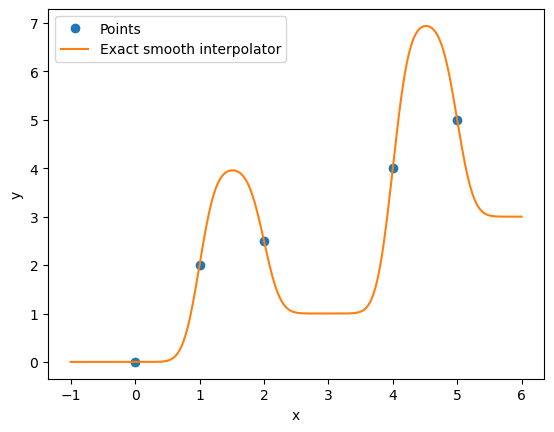

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

def smooth_step_matrix(x_vals, k):
    """Construct the basis matrix Phi where Phi[j,i] = smooth_step(x_j, k, x_i)."""
    n = len(x_vals)
    Phi = np.ones((n, n))
    for j in range(n):
        for i in range(1, n):
            Phi[j,i] = 0.5 * (1 + erf(k * (x_vals[j] - x_vals[i]) / sqrt(2)))
    return Phi

def smooth_monotone_interpolator(x_vals, y_vals, k = 5):
    """Return interpolator f(x) that smoothly interpolates points exactly."""
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)

    Phi = smooth_step_matrix(x_vals, k)

    # solve Phi * a = y
    a = np.linalg.solve(Phi, y_vals)

    def interpolator(x):
        """Evaluate interpolator at arbitrary x."""
        s = 0.0
        for i in range(len(a)):
            s += a[i] * 0.5 * (1 + erf(k * (x - x_vals[i]) / sqrt(2)))
        return s
    
    return interpolator

# Sample points (monotone non-decreasing y_vals!)
x_vals = [0, 1, 2, 4, 5]
y_vals = [0, 2, 2.5, 4, 5]

# Build interpolator
f = smooth_monotone_interpolator(x_vals, y_vals, k = 5)

# Plot result
xs = np.linspace(min(x_vals)-1, max(x_vals)+1, 500)
ys = [f(x) for x in xs]

plt.plot(x_vals, y_vals, 'o', label='Points')
plt.plot(xs, ys, '-', label='Exact smooth interpolator')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


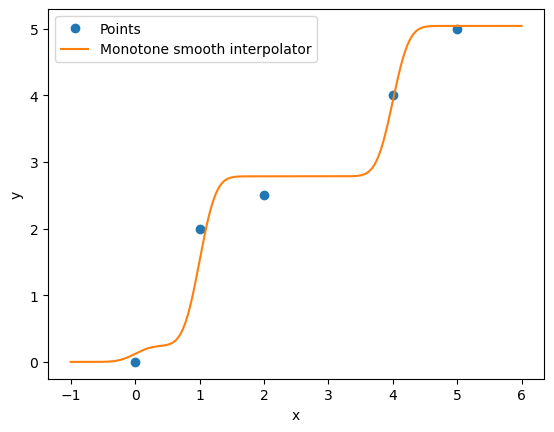

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt
from scipy.optimize import minimize

def smooth_step_matrix(x_vals, k):
    """Basis matrix for smooth step functions."""
    n = len(x_vals)
    Phi = np.ones((n, n))
    for j in range(n):
        for i in range(1, n):
            Phi[j,i] = 0.5 * (1 + erf(k * (x_vals[j] - x_vals[i]) / sqrt(2)))
    return Phi

def smooth_monotone_interpolator(x_vals, y_vals, k = 5):
    """Create smooth, monotone interpolator matching points exactly and w_i >= 0."""
    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    Phi = smooth_step_matrix(x_vals, k)

    n = len(x_vals)

    # minimize ||Phi w - y||^2 subject to w_i >= 0
    def objective(w):
        return np.linalg.norm(Phi @ w - y_vals)**2
    
    bounds = [(0, None)] * n
    res = minimize(objective, x0=y_vals.copy(), bounds=bounds)

    w = res.x

    def interpolator(x):
        """Evaluate interpolator at arbitrary x."""
        s = 0.0
        for i in range(n):
            s += w[i] * 0.5 * (1 + erf(k * (x - x_vals[i]) / sqrt(2)))
        return s
    
    return interpolator, w

# Sample points (monotone non-decreasing!)
x_vals = [0, 1, 2, 4, 5]
y_vals = [0, 2, 2.5, 4, 5]

# Build interpolator
f, w = smooth_monotone_interpolator(x_vals, y_vals, k = 5)

# Plot result
xs = np.linspace(min(x_vals)-1, max(x_vals)+1, 500)
ys = [f(x) for x in xs]

plt.plot(x_vals, y_vals, 'o', label='Points')
plt.plot(xs, ys, '-', label='Monotone smooth interpolator')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


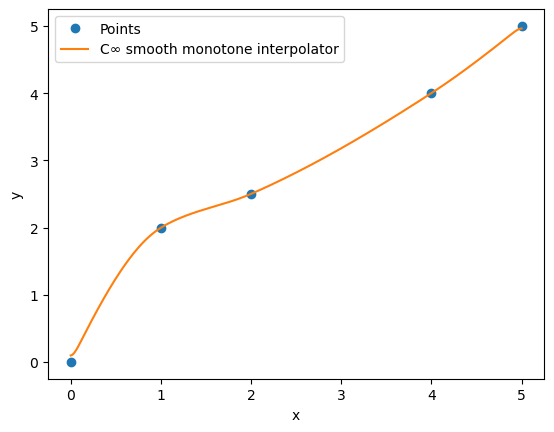

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.ndimage import gaussian_filter1d

def smooth_monotone_interpolator(x_vals, y_vals, sigma = 0.05, n = 500):
    """Create smooth, monotone interpolator from points by smoothing PCHIP."""
    pchip = PchipInterpolator(x_vals, y_vals)

    xs = np.linspace(min(x_vals), max(x_vals), n)
    p_vals = pchip(xs)

    # Apply tiny Gaussian smoothing
    p_smooth = gaussian_filter1d(p_vals, sigma=sigma * n / (max(x_vals)-min(x_vals)))

    return xs, p_smooth

# Sample points (monotone non-decreasing!)
x_vals = [0, 1, 2, 4, 5]
y_vals = [0, 2, 2.5, 4, 5]

# Smooth interpolator
xs, p_smooth = smooth_monotone_interpolator(x_vals, y_vals, sigma = 0.05)

# Plot
plt.plot(x_vals, y_vals, 'o', label='Points')
plt.plot(xs, p_smooth, '-', label='C∞ smooth monotone interpolator')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()


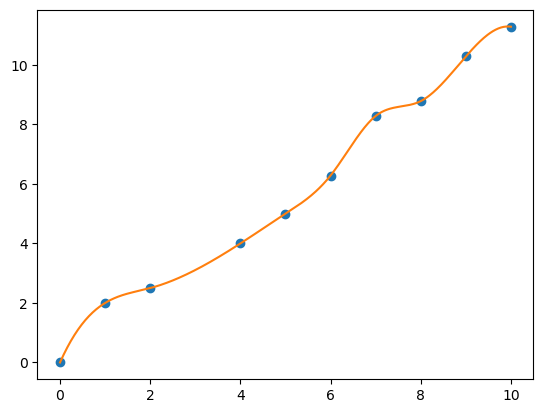

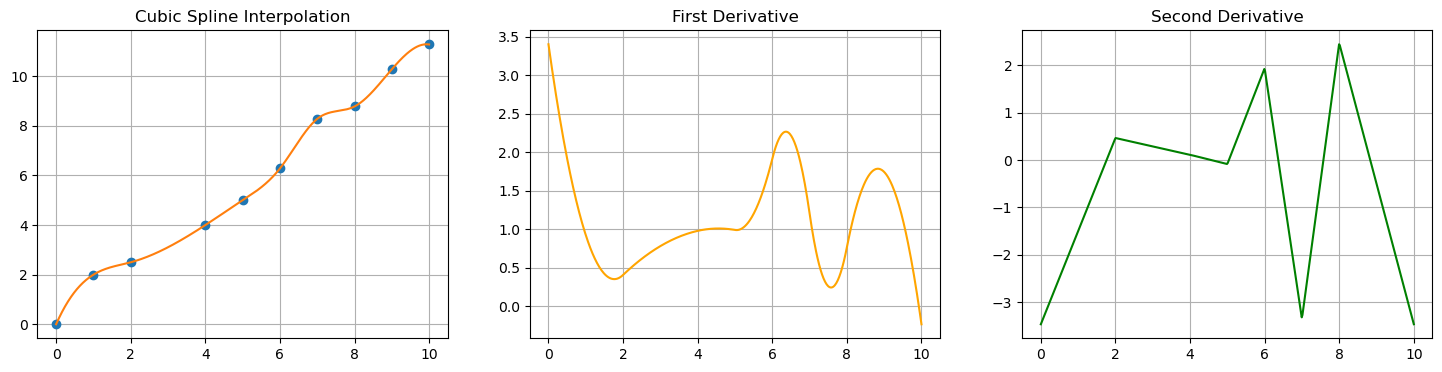

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Sample points
x_vals = [0, 1, 2, 4, 5, 6, 7, 8, 9, 10]
y_vals = [0, 2, 2.5, 4, 5, 2*np.pi, 2*np.pi+2, 2*np.pi + 2.5, 2*np.pi + 4, 2*np.pi + 5]

# Construct a cubic spline interpolator
cs = CubicSpline(x_vals, y_vals)

# Evaluate interpolator on a fine grid
xs = np.linspace(min(x_vals), max(x_vals), 500)
ys = cs(xs)

# Plot points and interpolator
plt.plot(x_vals, y_vals, 'o', label='Points')
plt.plot(xs, ys, '-', label='C^2 cubic spline interpolator')

# To visualize smoothness, we can compute first and second derivatives:
ys_prime = cs.derivative(1)(xs)  # first derivative
ys_second = cs.derivative(2)(xs)  # second derivative

# Plot first and second derivative in separate graphs
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].plot(x_vals, y_vals, 'o')
axs[0].plot(xs, ys, '-')
axs[0].set_title('Cubic Spline Interpolation')

axs[1].plot(xs, ys_prime, '-', color='orange')
axs[1].set_title('First Derivative')

axs[2].plot(xs, ys_second, '-', color='green')
axs[2].set_title('Second Derivative')

for ax in axs:
    ax.grid()

plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define points on [0, 2*pi]
x_vals = np.linspace(0, 2 * np.pi, 5, endpoint=False)  # 5 points evenly spaced
y_vals = np.sin(x_vals)  # periodic data (sin is periodic)

# To make it periodic, we use bc_type='periodic'
cs = CubicSpline(x_vals, y_vals, bc_type='periodic')

# Evaluate interpolator on a fine grid
xs = np.linspace(0, 2 * np.pi, 500)
ys = cs(xs)

# Plot points and interpolator
plt.plot(x_vals, y_vals, 'o', label='Points')
plt.plot(xs, ys, '-', label='Periodic cubic spline')

# To visualize periodic match at the boundary:
plt.axvline(0, color='grey', linestyle='--')
plt.axvline(2 * np.pi, color='grey', linestyle='--')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Periodic Cubic Spline')
plt.show()


ValueError: The first and last `y` point along axis 0 must be identical (within machine precision) when bc_type='periodic'.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define points on [0, 2*pi] (forming periodic pattern)
x_vals = np.linspace(0, 2 * np.pi, 7, endpoint=False)
y_vals = np.sin(x_vals)

# Construct periodic cubic spline interpolator
cs = CubicSpline(x_vals, y_vals, bc_type='periodic')

# Prepare to plot main and shifted copies
shift_vals = [0, 2 * np.pi, 4 * np.pi]  # 0, 1, and 2 periods forward

# Plot points first
for shift in shift_vals:
    plt.plot(x_vals + shift, y_vals, 'o', label=f'Points (+{shift})')

# Plot interpolator for each shift
xs = np.linspace(0, 2 * np.pi, 500)

for shift in shift_vals:
    xs_shifted = xs + shift
    ys = cs(xs)  # reuse interpolator directly
    plt.plot(xs_shifted, ys, '-', label=f'Spline (+{shift})')

plt.axvline(0, color='grey', linestyle='--')
for s in shift_vals[1:]:
    plt.axvline(s, color='grey', linestyle='--')

plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Periodic Cubic Spline and its Translations')
plt.grid()
plt.show()


ValueError: The first and last `y` point along axis 0 must be identical (within machine precision) when bc_type='periodic'.

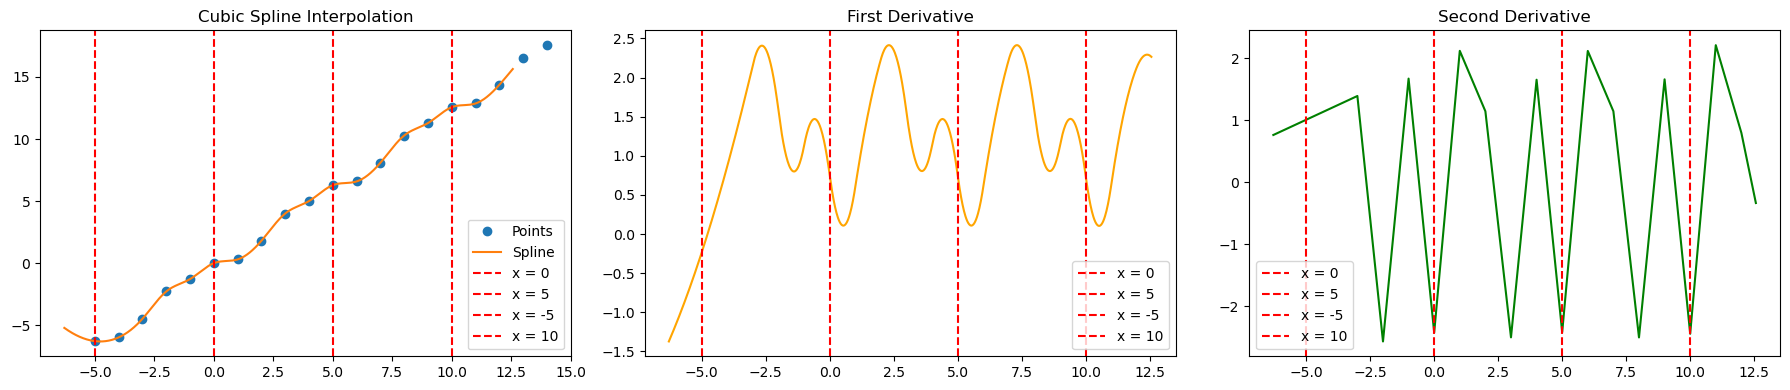

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Original points
x_vals = np.array([0,1,2,3,4])
y_vals = np.array([0,0.3,1.8,4.0,5.0])

# Prepare points shifted by -2pi and +2pi
y_vals_extended = np.concatenate([y_vals - 2 * np.pi, y_vals, y_vals + 2 * np.pi, y_vals + 4 * np.pi])
x_vals_extended = np.concatenate([x_vals - 5, x_vals, x_vals+5, x_vals+10])

# Sort points by x
sorted_indices = np.argsort(x_vals_extended)
x_vals_extended = x_vals_extended[sorted_indices]
y_vals_extended = y_vals_extended[sorted_indices]

# Construct a normal cubic spline through the extended points
cs = CubicSpline(x_vals_extended, y_vals_extended)

# Prepare points to evaluate
xs = np.linspace(-2 * np.pi, 4 * np.pi, 1000)

# Evaluate interpolator and its first and second derivative
ys = cs(xs)
ys_prime = cs.derivative(1)(xs)
ys_second = cs.derivative(2)(xs)

# Plot the results
fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].plot(x_vals_extended, y_vals_extended, 'o', label='Points')
axs[0].plot(xs, ys, '-', label='Spline')
axs[0].set_title('Cubic Spline Interpolation')

axs[1].plot(xs, ys_prime, '-', color='orange')
axs[1].set_title('First Derivative')

axs[2].plot(xs, ys_second, '-', color='green')
axs[2].set_title('Second Derivative')


# Add markers at x = 0, 5, -5
for ax in axs:
    for marker in [0, 5, -5, 10]:
        ax.axvline(marker, color='red', linestyle='--', label=f'x = {marker}')
    ax.legend()
    ax.grid()

    
for ax in axs:
    ax.grid()

fig.tight_layout()
plt.show()
